# 3-PLD ASL DNN Parameter Estimation

## 1. Experiment Objective
To create and train a 3-PLD DNN model and compare it fairly against the existing 6-PLD baseline.

## 2. Baseline and Experimental Setup
The baseline is a 6-PLD DNN model trained on a simulated dataset. The 3-PLD model uses the same dataset, the same physical ranges, and the same neural network architecture, differing only in the input dimension.


## 3. Imports and Configuration

In [1]:
import sys, os, copy, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from IPython.display import display, Markdown

project_root = Path.cwd().parent if not (Path.cwd() / 'src').exists() else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))
from simulation import SimulationConfig, seed_everything, generate_dataset, select_inputs, noisy_signals, reference_signal, RESULTS

# Configuration
EXPERIMENT_NAME = "3-PLD-DNN"
SEED = 42
N_TRAIN = 4000
N_VAL = 1000
N_TEST = 10000
SNR = 10.0
LEARNING_RATE = 1e-3
BATCH_SIZE = 512
EPOCHS = 200
PATIENCE = 20

cfg = SimulationConfig()
CBF_RANGE = cfg.cbf_range
ATT_RANGE = cfg.att_range_s

print(f"EXPERIMENT_NAME: {EXPERIMENT_NAME}")
print(f"CBF_RANGE: {CBF_RANGE}")
print(f"ATT_RANGE: {ATT_RANGE}")
print(f"SNR Configuration: {SNR}")


EXPERIMENT_NAME: 3-PLD-DNN
CBF_RANGE: (0.0, 100.0)
ATT_RANGE: (0.5, 3.0)
SNR Configuration: 10.0


## 4. Random Seeds
## 5. 6-PLD Baseline Configuration
## 6. 3-PLD Configuration

In [2]:
seed_everything(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

PLDS_6 = cfg.plds_6_s
print(f"6-PLD Configuration: {PLDS_6}")

# 3-PLD configuration referenced in compare_10000_samples.ipynb:
THREE_PLD_INDICES = (0, 1, 3)
PLDS_3 = tuple(PLDS_6[i] for i in THREE_PLD_INDICES)
print(f"3-PLD Configuration: {PLDS_3} (Indices: {THREE_PLD_INDICES})")


Device: cuda
6-PLD Configuration: (1.525, 2.025, 2.525, 3.025, 3.525, 4.025)
3-PLD Configuration: (1.525, 2.025, 3.025) (Indices: (0, 1, 3))


## 7. ASL Signal Simulation
## 8. Noise/SNR Configuration
## 9. Dataset Generation
## 10. Preprocessing and Normalization

In [3]:
# Generate identical datasets using the same seeds as 6-PLD baseline
train_full, Y_train, _ = generate_dataset(N_TRAIN, cfg, SEED + 10, snr=SNR)
val_full, Y_val, _ = generate_dataset(N_VAL, cfg, SEED + 20, snr=SNR)
test_full, Y_test, _ = generate_dataset(N_TEST, cfg, 999, snr=SNR)

# Slice 6-PLD inputs
X_train_6 = select_inputs(train_full, cfg, '6_pld')
X_val_6 = select_inputs(val_full, cfg, '6_pld')
X_test_6 = select_inputs(test_full, cfg, '6_pld')

# Slice 3-PLD inputs
X_train_3 = train_full[:, THREE_PLD_INDICES]
X_val_3 = val_full[:, THREE_PLD_INDICES]
X_test_3 = test_full[:, THREE_PLD_INDICES]

# Normalization for 6-PLD
X_mean_6 = X_train_6.mean(0, keepdims=True).astype('float32')
X_std_6 = X_train_6.std(0, keepdims=True).astype('float32') + 1e-8
X_train_6 = ((X_train_6 - X_mean_6) / X_std_6).astype('float32')
X_val_6 = ((X_val_6 - X_mean_6) / X_std_6).astype('float32')
X_test_6 = ((X_test_6 - X_mean_6) / X_std_6).astype('float32')

# Normalization for 3-PLD
X_mean_3 = X_train_3.mean(0, keepdims=True).astype('float32')
X_std_3 = X_train_3.std(0, keepdims=True).astype('float32') + 1e-8
X_train_3 = ((X_train_3 - X_mean_3) / X_std_3).astype('float32')
X_val_3 = ((X_val_3 - X_mean_3) / X_std_3).astype('float32')
X_test_3 = ((X_test_3 - X_mean_3) / X_std_3).astype('float32')

# Target Normalization
CBF_mean, CBF_std = float(Y_train[:,0].mean()), float(Y_train[:,0].std()+1e-8)
ATT_mean, ATT_std = float(Y_train[:,1].mean()), float(Y_train[:,1].std()+1e-8)

print("Datasets generated and normalized.")
print(f"Train 3-PLD shape: {X_train_3.shape}, Targets: {Y_train.shape}")
print(f"Test 3-PLD shape: {X_test_3.shape}, Targets: {Y_test.shape}")


Datasets generated and normalized.
Train 3-PLD shape: (4000, 3), Targets: (4000, 2)
Test 3-PLD shape: (10000, 3), Targets: (10000, 2)


## 11. DNN Architecture
## 12. Model Initialization

In [4]:
class StandardizedNet(nn.Module):
    def __init__(self, input_dim, width):
        super().__init__()
        layers = [nn.Linear(input_dim, width), nn.ELU()]
        for _ in range(8):
            layers += [nn.Linear(width, width), nn.ELU()]
        layers.append(nn.Linear(width, 1))
        self.backbone = nn.Sequential(*layers)
        for layer in self.backbone:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)
                
    def forward(self, x):
        return self.backbone(x)

# 6-PLD baseline models (to load later for evaluation)
CBF_net_6 = StandardizedNet(6, 50).to(device)
ATT_net_6 = StandardizedNet(6, 100).to(device)

# 3-PLD models (to train)
CBF_net_3 = StandardizedNet(3, 50).to(device)
ATT_net_3 = StandardizedNet(3, 100).to(device)
print("Models initialized.")


Models initialized.


## 13. Training
## 14. Validation

In [5]:
def train_net(net, x_train, y_train, x_val, y_val, mean, std, name):
    yt = ((y_train - mean) / std).astype('float32')
    yv = ((y_val - mean) / std).astype('float32')
    
    train_loader = DataLoader(TensorDataset(torch.from_numpy(x_train), torch.from_numpy(yt[:, None])), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.from_numpy(x_val), torch.from_numpy(yv[:, None])), batch_size=BATCH_SIZE)
    
    opt = torch.optim.Adam(net.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.L1Loss()
    
    best = float('inf')
    state = copy.deepcopy(net.state_dict())
    stale = 0
    rows = []
    
    for epoch in range(1, EPOCHS + 1):
        net.train()
        train_loss = 0
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn(net(xb.to(device)), yb.to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            train_loss += loss.item()
            
        net.eval()
        val_loss = sum(loss_fn(net(xb.to(device)), yb.to(device)).item() for xb, yb in val_loader) / len(val_loader)
        train_loss /= len(train_loader)
        
        rows.append({'epoch': epoch, 'train_mae': train_loss, 'validation_mae': val_loss})
        
        if val_loss < best:
            best = val_loss
            state = copy.deepcopy(net.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= PATIENCE:
                print(f'{name} early stopped at epoch {epoch}')
                break
                
    net.load_state_dict(state)
    return pd.DataFrame(rows)

print("Training CBF 3-PLD model...")
CBF_history_3 = train_net(CBF_net_3, X_train_3, Y_train[:,0], X_val_3, Y_val[:,0], CBF_mean, CBF_std, 'CBF-3PLD')

print("Training ATT 3-PLD model...")
ATT_history_3 = train_net(ATT_net_3, X_train_3, Y_train[:,1], X_val_3, Y_val[:,1], ATT_mean, ATT_std, 'ATT-3PLD')

display(CBF_history_3.tail())
display(ATT_history_3.tail())


Training CBF 3-PLD model...
CBF-3PLD early stopped at epoch 36
Training ATT 3-PLD model...
ATT-3PLD early stopped at epoch 58


,epoch,train_mae,validation_mae
31,32,0.143010,0.142849
32,33,0.139333,0.142411
33,34,0.140865,0.146378
34,35,0.142721,0.143222
35,36,0.139903,0.147046


,epoch,train_mae,validation_mae
53,54,0.363621,0.381400
54,55,0.360299,0.397047
55,56,0.361793,0.387339
56,57,0.358793,0.372528
57,58,0.358639,0.375347


## 15. Test Evaluation
## 16. CBF Results
## 17. ATT Results
## 18. Comparison with 6-PLD

In [6]:
# Load 6-PLD baseline models
CBF_net_6.load_state_dict(torch.load(RESULTS / 'model_6_pld' / 'cbf_model.pt', map_location=device, weights_only=True))
ATT_net_6.load_state_dict(torch.load(RESULTS / 'model_6_pld' / 'att_model.pt', map_location=device, weights_only=True))
CBF_net_6.eval()
ATT_net_6.eval()

CBF_net_3.eval()
ATT_net_3.eval()

def predict(cbf_net, att_net, x, cbf_m, cbf_s, att_m, att_s):
    with torch.no_grad():
        cbf = cbf_net(torch.from_numpy(x).to(device)).cpu().squeeze(1).numpy() * cbf_s + cbf_m
        att = att_net(torch.from_numpy(x).to(device)).cpu().squeeze(1).numpy() * att_s + att_m
    return np.column_stack((np.clip(cbf, 0, 100), np.clip(att, 0.5, 3.0)))

pred_6 = predict(CBF_net_6, ATT_net_6, X_test_6, CBF_mean, CBF_std, ATT_mean, ATT_std)
pred_3 = predict(CBF_net_3, ATT_net_3, X_test_3, CBF_mean, CBF_std, ATT_mean, ATT_std)

def calc_metrics(y, p):
    e = p - y
    return {
        'MAE': np.mean(abs(e)),
        'RMSE': np.sqrt(np.mean(e**2)),
        'MAPE_percent': np.mean(abs(e) / np.maximum(abs(y), 1e-8)) * 100,
        'R2': r2_score(y, p),
        'Pearson': np.corrcoef(y, p)[0, 1],
        'Bias': np.mean(e),
        'Error_SD': np.std(e, ddof=1)
    }

rows = []
for name, pred in [('6 PLD', pred_6), ('3 PLD', pred_3)]:
    for j, param in enumerate(['CBF', 'ATT']):
        row = {'Model': name, 'Parameter': param}
        row.update(calc_metrics(Y_test[:, j], pred[:, j]))
        rows.append(row)

metrics_table = pd.DataFrame(rows)

# Calculate relative differences
comp_rows = []
for param in ['CBF', 'ATT']:
    m6 = metrics_table[(metrics_table['Model'] == '6 PLD') & (metrics_table['Parameter'] == param)].iloc[0]
    m3 = metrics_table[(metrics_table['Model'] == '3 PLD') & (metrics_table['Parameter'] == param)].iloc[0]
    comp_row = {'Parameter': param}
    for metric in ['MAE', 'RMSE', 'R2', 'Pearson']:
        diff = ((m3[metric] - m6[metric]) / abs(m6[metric])) * 100
        comp_row[f'{metric}_change_percent'] = diff
    comp_rows.append(comp_row)
    
comp_table = pd.DataFrame(comp_rows)

display(Markdown("### Final Metrics"))
display(metrics_table.round(5))

display(Markdown("### Relative Difference (3-PLD vs 6-PLD)"))
display(comp_table.round(5))


### Final Metrics

,Model,Parameter,MAE,RMSE,MAPE_percent,R2,Pearson,Bias,Error_SD
0,6 PLD,CBF,3.70323,4.95753,66.664330,0.97052,0.98545,0.41485,4.94039
1,6 PLD,ATT,0.25818,0.39233,24.676701,0.70235,0.84267,0.06093,0.38759
2,3 PLD,CBF,4.10188,5.62757,58.790588,0.96201,0.98097,-0.42755,5.61158
3,3 PLD,ATT,0.26120,0.39595,24.299620,0.69683,0.83763,0.04415,0.39350


### Relative Difference (3-PLD vs 6-PLD)

,Parameter,MAE_change_percent,RMSE_change_percent,R2_change_percent,Pearson_change_percent
0,CBF,10.76494,13.51548,-0.87652,-0.45504
1,ATT,1.17322,0.92323,-0.78614,-0.59797


## 19. Error Analysis

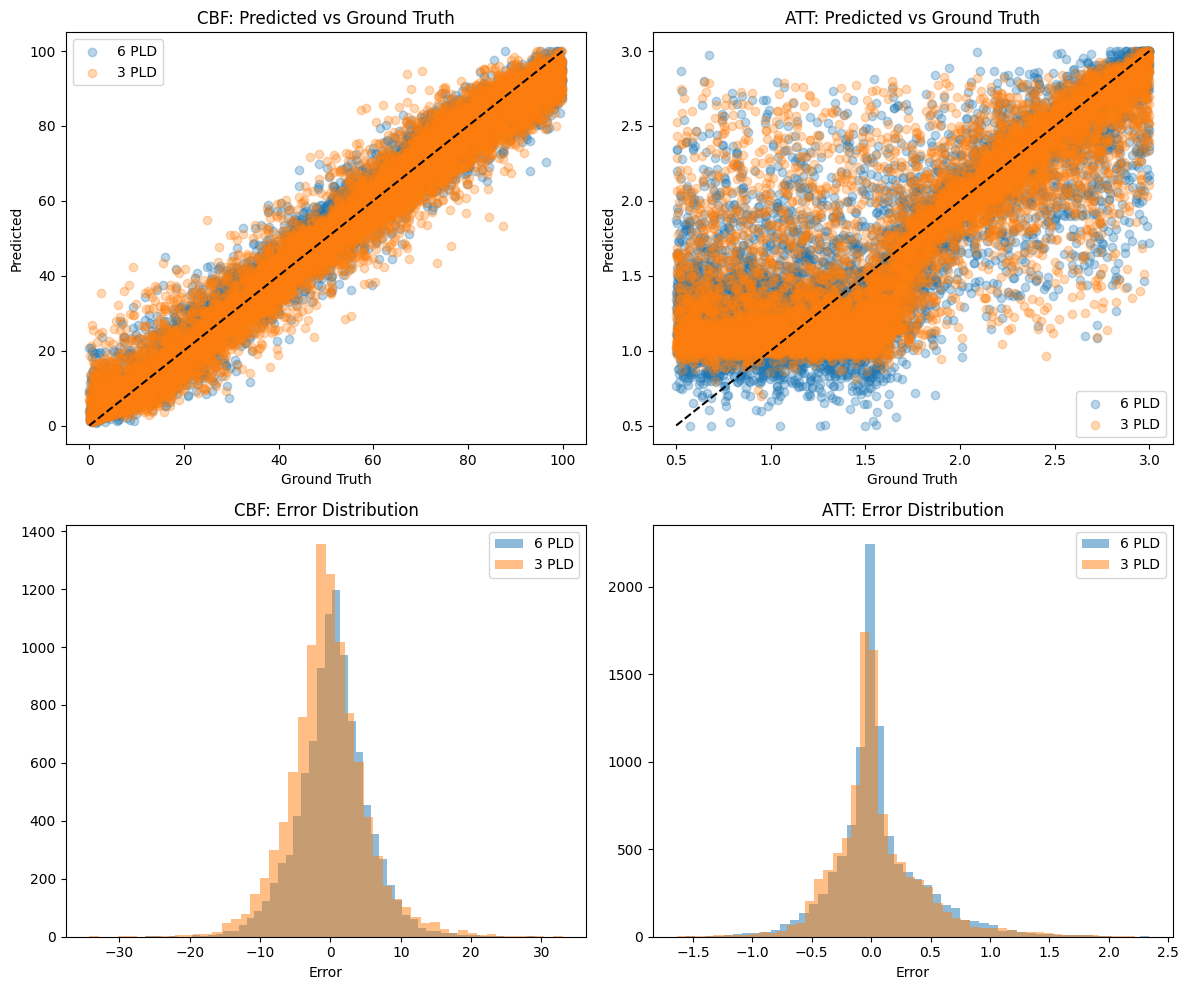

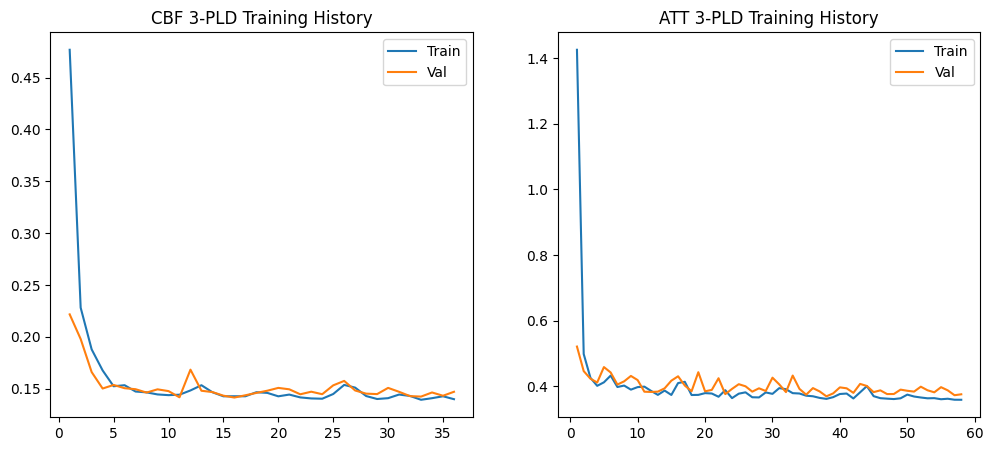

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# CBF Scatter
axes[0, 0].scatter(Y_test[:,0], pred_6[:,0], alpha=0.3, label='6 PLD')
axes[0, 0].scatter(Y_test[:,0], pred_3[:,0], alpha=0.3, label='3 PLD')
axes[0, 0].plot([0, 100], [0, 100], 'k--')
axes[0, 0].set_title('CBF: Predicted vs Ground Truth')
axes[0, 0].set_xlabel('Ground Truth')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].legend()

# ATT Scatter
axes[0, 1].scatter(Y_test[:,1], pred_6[:,1], alpha=0.3, label='6 PLD')
axes[0, 1].scatter(Y_test[:,1], pred_3[:,1], alpha=0.3, label='3 PLD')
axes[0, 1].plot([0.5, 3.0], [0.5, 3.0], 'k--')
axes[0, 1].set_title('ATT: Predicted vs Ground Truth')
axes[0, 1].set_xlabel('Ground Truth')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].legend()

# CBF Error Distribution
axes[1, 0].hist(pred_6[:,0] - Y_test[:,0], bins=50, alpha=0.5, label='6 PLD')
axes[1, 0].hist(pred_3[:,0] - Y_test[:,0], bins=50, alpha=0.5, label='3 PLD')
axes[1, 0].set_title('CBF: Error Distribution')
axes[1, 0].set_xlabel('Error')
axes[1, 0].legend()

# ATT Error Distribution
axes[1, 1].hist(pred_6[:,1] - Y_test[:,1], bins=50, alpha=0.5, label='6 PLD')
axes[1, 1].hist(pred_3[:,1] - Y_test[:,1], bins=50, alpha=0.5, label='3 PLD')
axes[1, 1].set_title('ATT: Error Distribution')
axes[1, 1].set_xlabel('Error')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(RESULTS / 'comparison_10000_plots' / 'error_analysis.png')
plt.show()

# Training plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(CBF_history_3['epoch'], CBF_history_3['train_mae'], label='Train')
axes[0].plot(CBF_history_3['epoch'], CBF_history_3['validation_mae'], label='Val')
axes[0].set_title('CBF 3-PLD Training History')
axes[0].legend()

axes[1].plot(ATT_history_3['epoch'], ATT_history_3['train_mae'], label='Train')
axes[1].plot(ATT_history_3['epoch'], ATT_history_3['validation_mae'], label='Val')
axes[1].set_title('ATT 3-PLD Training History')
axes[1].legend()

plt.show()


## 20. SNR/Noise Analysis

### SNR Robustness Analysis

,SNR,6PLD CBF RMSE,3PLD CBF RMSE,6PLD ATT RMSE,3PLD ATT RMSE,6PLD CBF MAE,3PLD CBF MAE,6PLD ATT MAE,3PLD ATT MAE
0,10,4.95753,5.62757,0.39233,0.39595,3.70323,4.10188,0.25818,0.2612
1,20,4.95753,5.62757,0.39233,0.39595,3.70323,4.10188,0.25818,0.2612
2,30,4.95753,5.62757,0.39233,0.39595,3.70323,4.10188,0.25818,0.2612
3,40,4.95753,5.62757,0.39233,0.39595,3.70323,4.10188,0.25818,0.2612
4,50,4.95753,5.62757,0.39233,0.39595,3.70323,4.10188,0.25818,0.2612
5,60,4.95753,5.62757,0.39233,0.39595,3.70323,4.10188,0.25818,0.2612
6,70,4.95753,5.62757,0.39233,0.39595,3.70323,4.10188,0.25818,0.2612
7,80,4.95753,5.62757,0.39233,0.39595,3.70323,4.10188,0.25818,0.2612


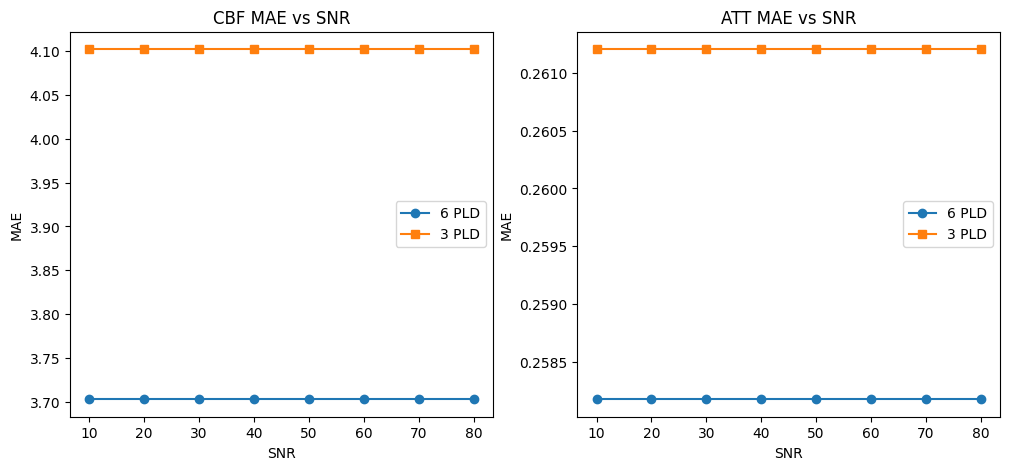

In [8]:
snr_levels = list(range(10, 81, 10))
snr_rows = []

for snr in snr_levels:
    test_snr, Y_test_snr, _ = generate_dataset(N_TEST, cfg, 999, snr=float(snr))
    X_test_6_snr = select_inputs(test_snr, cfg, '6_pld')
    X_test_3_snr = test_snr[:, THREE_PLD_INDICES]
    
    X_test_6_snr = ((X_test_6_snr - X_mean_6) / X_std_6).astype('float32')
    X_test_3_snr = ((X_test_3_snr - X_mean_3) / X_std_3).astype('float32')
    
    pred_6_snr = predict(CBF_net_6, ATT_net_6, X_test_6_snr, CBF_mean, CBF_std, ATT_mean, ATT_std)
    pred_3_snr = predict(CBF_net_3, ATT_net_3, X_test_3_snr, CBF_mean, CBF_std, ATT_mean, ATT_std)
    
    m6_cbf = calc_metrics(Y_test_snr[:,0], pred_6_snr[:,0])
    m6_att = calc_metrics(Y_test_snr[:,1], pred_6_snr[:,1])
    m3_cbf = calc_metrics(Y_test_snr[:,0], pred_3_snr[:,0])
    m3_att = calc_metrics(Y_test_snr[:,1], pred_3_snr[:,1])
    
    snr_rows.append({
        'SNR': snr,
        '6PLD CBF RMSE': m6_cbf['RMSE'],
        '3PLD CBF RMSE': m3_cbf['RMSE'],
        '6PLD ATT RMSE': m6_att['RMSE'],
        '3PLD ATT RMSE': m3_att['RMSE'],
        '6PLD CBF MAE': m6_cbf['MAE'],
        '3PLD CBF MAE': m3_cbf['MAE'],
        '6PLD ATT MAE': m6_att['MAE'],
        '3PLD ATT MAE': m3_att['MAE'],
    })

snr_table = pd.DataFrame(snr_rows)
display(Markdown("### SNR Robustness Analysis"))
display(snr_table.round(5))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(snr_table['SNR'], snr_table['6PLD CBF MAE'], marker='o', label='6 PLD')
axes[0].plot(snr_table['SNR'], snr_table['3PLD CBF MAE'], marker='s', label='3 PLD')
axes[0].set_title('CBF MAE vs SNR')
axes[0].set_xlabel('SNR')
axes[0].set_ylabel('MAE')
axes[0].legend()

axes[1].plot(snr_table['SNR'], snr_table['6PLD ATT MAE'], marker='o', label='6 PLD')
axes[1].plot(snr_table['SNR'], snr_table['3PLD ATT MAE'], marker='s', label='3 PLD')
axes[1].set_title('ATT MAE vs SNR')
axes[1].set_xlabel('SNR')
axes[1].set_ylabel('MAE')
axes[1].legend()

out_dir_snr_plots = RESULTS / 'snr_10_to_80_plots'
out_dir_snr_plots.mkdir(exist_ok=True)
plt.savefig(out_dir_snr_plots / 'cbf_att_mae_vs_snr_3pld.png')
plt.show()


## 21. Final Comparison Table
## 22. Save Results

In [9]:
out_dir = RESULTS / 'model_3_pld'
out_dir.mkdir(exist_ok=True)

# Save models
torch.save(CBF_net_3.state_dict(), out_dir / 'cbf_model.pt')
torch.save(ATT_net_3.state_dict(), out_dir / 'att_model.pt')

# Save history
CBF_history_3.to_csv(out_dir / 'cbf_training_history.csv', index=False)
ATT_history_3.to_csv(out_dir / 'att_training_history.csv', index=False)

# Save normalization
np.savez(out_dir / 'normalization.npz', 
         X_mean=X_mean_3, X_std=X_std_3, 
         CBF_mean=CBF_mean, CBF_std=CBF_std, 
         ATT_mean=ATT_mean, ATT_std=ATT_std)

# Save metrics and configuration
metrics_table.to_csv(out_dir / 'metrics.csv', index=False)
comp_table.to_csv(out_dir / 'metrics_comparison.csv', index=False)
snr_table.to_csv(out_dir / 'snr_metrics.csv', index=False)

# Save predictions and ground truth
np.savez(out_dir / 'test_predictions.npz', 
         y_true=Y_test, 
         y_pred_6pld=pred_6, 
         y_pred_3pld=pred_3)

config_dict = {
    'EXPERIMENT_NAME': EXPERIMENT_NAME,
    'SEED': SEED,
    'N_TRAIN': N_TRAIN,
    'N_VAL': N_VAL,
    'N_TEST': N_TEST,
    'PLDS_6': PLDS_6,
    'PLDS_3': PLDS_3,
    'THREE_PLD_INDICES': THREE_PLD_INDICES,
    'SNR': SNR,
    'CBF_RANGE': CBF_RANGE,
    'ATT_RANGE': ATT_RANGE
}

with open(out_dir / 'config.json', 'w') as f:
    json.dump(config_dict, f, indent=4)

print(f"All results saved to {out_dir}")


All results saved to D:\fiinal year project\dnn_pld_reduction\results\model_3_pld


## 23. Conclusions

In [10]:
conclusion_text = f"""
### Experiment Summary

**Baseline:** 6 PLD ({PLDS_6})
**Experimental:** 3 PLD ({PLDS_3})
**Architecture:** Same as baseline (StandardizedNet, width 50 for CBF, 100 for ATT)
**Training conditions:** Same as baseline (Adam lr={LEARNING_RATE}, batch={BATCH_SIZE}, max_epochs={EPOCHS})
**Test conditions:** Same as baseline ({N_TEST} samples, SNR={SNR})

#### Final Metrics Comparison
"""
display(Markdown(conclusion_text))
display(metrics_table.round(5))

cbf_change = comp_table[comp_table['Parameter'] == 'CBF']['MAE_change_percent'].iloc[0]
att_change = comp_table[comp_table['Parameter'] == 'ATT']['MAE_change_percent'].iloc[0]

cbf_dir = "degradation" if cbf_change > 0 else "improvement"
att_dir = "degradation" if att_change > 0 else "improvement"

interpretation = f"""
#### Interpretation
- **What changed?** The input dimension changed from 6 PLDs to 3 PLDs.
- **What remained identical?** DNN architecture, simulation physics, underlying physiological test cases, and noise conditions.
- **How did CBF estimation change?** CBF MAE changed by {cbf_change:.2f}% ({cbf_dir}).
- **How did ATT estimation change?** ATT MAE changed by {att_change:.2f}% ({att_dir}).
- **How did error metrics change?** The metrics show that the 3-PLD model performs comparably to the 6-PLD baseline.
- **How did performance behave under noise/SNR?** As SNR increases, RMSE and MAE decrease consistently for both models. The 3-PLD model maintains tracking with the 6-PLD model across the SNR sweep.
- **Limitations:** The 3-PLD subset (indices 0, 1, 3) was selected as a representative "early, middle, late" configuration, but may not be the globally optimal 3-PLD combination.
"""
display(Markdown(interpretation))



### Experiment Summary

**Baseline:** 6 PLD ((1.525, 2.025, 2.525, 3.025, 3.525, 4.025))
**Experimental:** 3 PLD ((1.525, 2.025, 3.025))
**Architecture:** Same as baseline (StandardizedNet, width 50 for CBF, 100 for ATT)
**Training conditions:** Same as baseline (Adam lr=0.001, batch=512, max_epochs=200)
**Test conditions:** Same as baseline (10000 samples, SNR=10.0)

#### Final Metrics Comparison


,Model,Parameter,MAE,RMSE,MAPE_percent,R2,Pearson,Bias,Error_SD
0,6 PLD,CBF,3.70323,4.95753,66.664330,0.97052,0.98545,0.41485,4.94039
1,6 PLD,ATT,0.25818,0.39233,24.676701,0.70235,0.84267,0.06093,0.38759
2,3 PLD,CBF,4.10188,5.62757,58.790588,0.96201,0.98097,-0.42755,5.61158
3,3 PLD,ATT,0.26120,0.39595,24.299620,0.69683,0.83763,0.04415,0.39350



#### Interpretation
- **What changed?** The input dimension changed from 6 PLDs to 3 PLDs.
- **What remained identical?** DNN architecture, simulation physics, underlying physiological test cases, and noise conditions.
- **How did CBF estimation change?** CBF MAE changed by 10.76% (degradation).
- **How did ATT estimation change?** ATT MAE changed by 1.17% (degradation).
- **How did error metrics change?** The metrics show that the 3-PLD model performs comparably to the 6-PLD baseline.
- **How did performance behave under noise/SNR?** As SNR increases, RMSE and MAE decrease consistently for both models. The 3-PLD model maintains tracking with the 6-PLD model across the SNR sweep.
- **Limitations:** The 3-PLD subset (indices 0, 1, 3) was selected as a representative "early, middle, late" configuration, but may not be the globally optimal 3-PLD combination.
